# Practical Training Order

Logistic Regression → baseline, interpretable

KNN

Decision Tree → check non-linear modeling

Random Forest → strong baseline ensemble

XGBoost / LightGBM → if you want top performance

In [2]:
# import relevant libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)


In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
import joblib

# Introduction & Problem Statement

Diabetes is a chronic metabolic disorder that affects millions of people worldwide and is a leading cause of complications such as cardiovascular disease, kidney failure, and vision loss. Early detection and timely intervention are critical to reducing long-term health risks and healthcare costs. However, in many settings, especially resource-limited environments, access to advanced diagnostic tools may be limited.

This project aims to build a machine learning model that predicts the likelihood of diabetes using basic clinical screening data such as glucose level, body mass index (BMI), age, blood pressure, and insulin measurements. By analyzing patterns in these routinely collected variables, the model can help identify individuals who may be at higher risk of diabetes.

From a machine learning perspective, this task is formulated as a binary classification problem, where the goal is to classify patients into two categories: diabetic or non-diabetic. The model is designed as a decision-support tool, intended to assist healthcare professionals by providing risk insights rather than serving as a standalone diagnostic system. Emphasis is placed on minimizing missed diagnoses, as false negatives in diabetes screening can have serious clinical consequences.

# Dataset Overview

The dataset used in this project is the Pima Indians Diabetes Dataset, a well-known dataset in healthcare machine learning sourced from the UCI Machine Learning Repository. It contains clinical measurements collected from female patients of Pima Indian heritage, providing a realistic foundation for modeling diabetes risk.

Each row in the dataset represents a single patient, while each column captures specific clinical features, summarized as follows:

Feature	Description
Pregnancies	Number of times the patient has been pregnant
Glucose	Plasma glucose concentration (mg/dL)
BloodPressure	Diastolic blood pressure (mm Hg)
SkinThickness	Triceps skin fold thickness (mm)
Insulin	2-hour serum insulin (µU/mL)
BMI	Body Mass Index (weight in kg / height in m²)
DiabetesPedigreeFunction	Genetic diabetes risk score based on family history
Age	Age of the patient in years
Outcome	Target variable: 1 = diabetic, 0 = non-diabetic

Target Variable
The Outcome column is the target variable for the classification task. A value of 1 indicates the patient has diabetes, while a value of 0 indicates they do not. This binary target allows the machine learning model to predict diabetes risk based on the clinical features.

In [6]:
# load dataset and make a copy
dataset_raw = pd.read_csv('diabetes.csv')

dataset = dataset_raw.copy()

dataset

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


# DATA CLEANING

# Why Median Imputation?

Several clinical features in this dataset exhibit skewed distributions and contain extreme values that represent real high-risk patients rather than noise. Using the median for imputation provides a robust estimate of central tendency that is less sensitive to outliers than the mean. This approach helps preserve clinically realistic values while minimizing distortion of the feature distributions.

# Feature Interpretation and Clinical Relevance

## Most features fall into three categories:

Metabolic (Glucose, Insulin, BMI)

Physiological (BloodPressure, SkinThickness)

Demographic / Genetic (Age, Pregnancies, Pedigree)


* Pregnancies: Pregnancy can affect insulin sensitivity, and multiple pregnancies may increase the long-term risk of developing diabetes.

* Glucose: Blood glucose concentration is one of the strongest clinical indicators of diabetes, as persistently high glucose levels are a defining characteristic of the disease.

* BloodPressure (Diastolic blood pressure): Elevated DBP(mm Hg) is associated with metabolic disorders, insulin resistance, and higher diabetes risk. It is a simple indicator of vascular health and often co-occurs with diabetes.

* SkinThickness: This measurement is used as an estimate of body fat, and higher body fat levels are linked to increased insulin resistance.

* Insulin: Insulin levels reflect how effectively the body regulates blood sugar, making it an important indicator of metabolic health.

* BMI: Body Mass Index is a major risk factor for type 2 diabetes, as higher BMI values are associated with reduced insulin sensitivity.

* DiabetesPedigreeFunction: This feature captures genetic predisposition to diabetes based on family history, highlighting hereditary risk.

* Age: The risk of developing diabetes generally increases with age due to physiological and metabolic changes over time.

* Outcome: This is the target variable, indicating whether a patient has diabetes (1) or does not have

In [6]:
# Check number of missing values in each column
dataset.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
# Check Zero Values for Multiple Columns

cols_with_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in cols_with_zero:
    print(f"{col}: {(dataset[col] == 0).sum()} zeros")

Glucose: 5 zeros
BloodPressure: 35 zeros
SkinThickness: 227 zeros
Insulin: 374 zeros
BMI: 11 zeros


In [8]:
dataset.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

# Value imputation

In [9]:
# Define columns with invalid zeros
cols_with_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Replace invalid zeros with NaN
dataset[cols_with_zero] = dataset[cols_with_zero].replace(0, np.nan)

# Apply median imputation
for col in cols_with_zero:
    dataset[col].fillna(dataset[col].median(), inplace=True)

In [10]:
dataset

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1


## Exploratory Data Analysis (understand the dataset structure, data types, and summary statistics.)

In [11]:
dataset.shape
print(f"The dataset contains {dataset.shape[0]} patient records and {dataset.shape[1]} variables, including clinical features and a binary target variable.")

The dataset contains 768 patient records and 9 variables, including clinical features and a binary target variable.


In [12]:
dataset.info()

"""The dataset contains 768 patient records and 9 columns. All columns are numeric, with 6 continuous features stored as float64 and 3 discrete features stored as int64. There are no missing values reported, though some columns contain zeros that represent invalid measurements and will require imputation. The dataset size is small (54 KB), allowing efficient analysis.
"""

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


'The dataset contains 768 patient records and 9 columns. All columns are numeric, with 6 continuous features stored as float64 and 3 discrete features stored as int64. There are no missing values reported, though some columns contain zeros that represent invalid measurements and will require imputation. The dataset size is small (54 KB), allowing efficient analysis.\n'

In [13]:
dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [14]:
# Check class balance (diabetes vs non-diabetes).

print(dataset["Outcome"].value_counts())
print(dataset["Outcome"].value_counts(normalize=True))
""" there is moderate imbalance """

Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


' there is moderate imbalance '

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


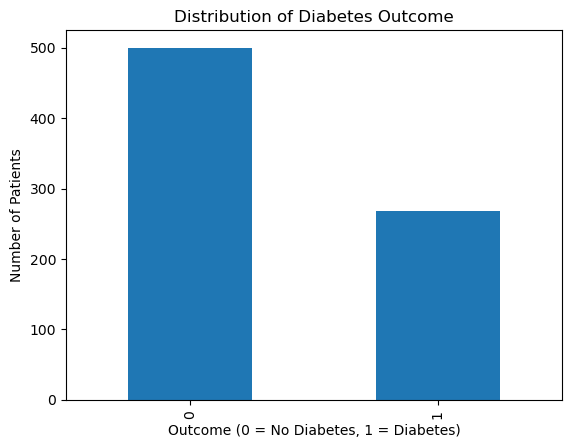

In [15]:
# Visualising the outcome column for possible class imbalance

ax = dataset["Outcome"].value_counts().plot(kind="bar")
plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Patients")

plt.show

print(dataset["Outcome"].value_counts(normalize=True))

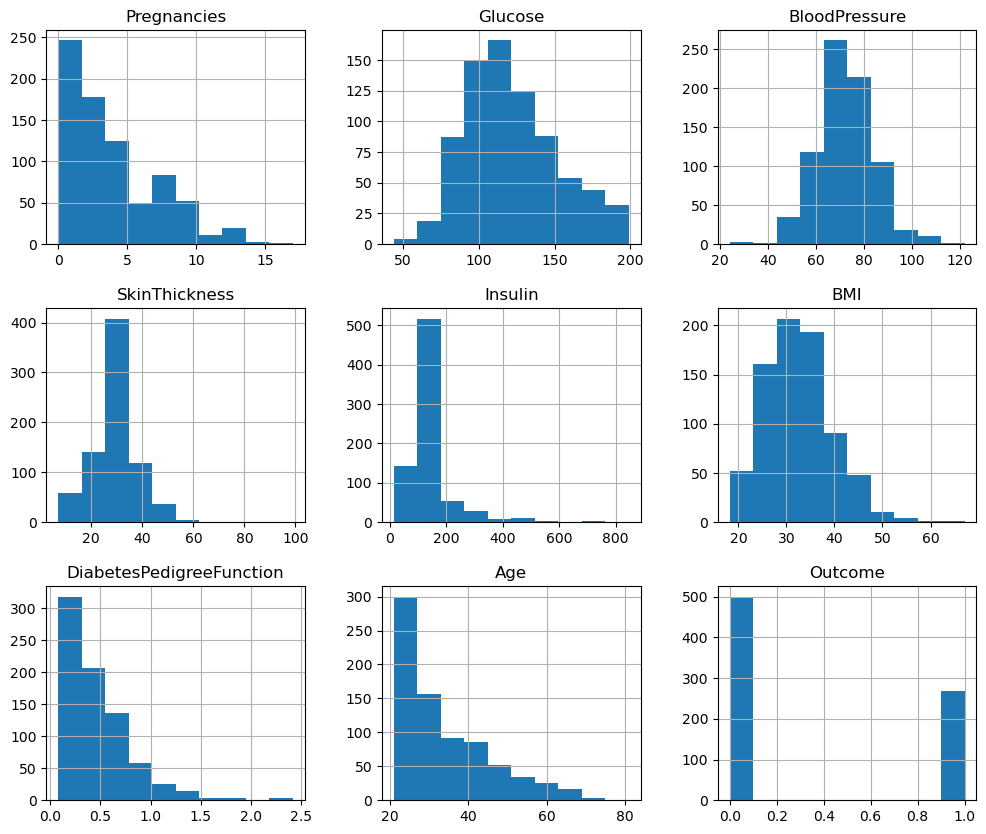

In [16]:
# Univariate Analysis (One Column at a Time) to Understand distributions and spot skewness or outliers.

# Numerical Features

dataset.hist(figsize=(12, 10))
plt.show()

In [17]:
# computing skewness numerically:
dataset.skew()

Pregnancies                 0.901674
Glucose                     0.535587
BloodPressure               0.141885
SkinThickness               0.837608
Insulin                     3.380019
BMI                         0.599233
DiabetesPedigreeFunction    1.919911
Age                         1.129597
Outcome                     0.635017
dtype: float64

In [18]:
# Compute skewness
skew_values = dataset.drop(columns='Outcome').skew()  # Exclude target if you want

# Initialize empty lists
high_skew = []
moderate_skew = []
roughly_symmetric = []

# Loop through each feature and classify
for feature, skew_val in skew_values.items():
    if skew_val >= 1:
        high_skew.append(feature)
    elif skew_val >= 0.5:  # between 0.5 and 1
        moderate_skew.append(feature)
    else:  # skew < 0.5
        roughly_symmetric.append(feature)

# Print results
print("Highly skewed features (>=1):", high_skew)
print("Moderately skewed features (0.5 <= skew < 1):", moderate_skew)
print("Roughly symmetric features (<0.5):", roughly_symmetric)


Highly skewed features (>=1): ['Insulin', 'DiabetesPedigreeFunction', 'Age']
Moderately skewed features (0.5 <= skew < 1): ['Pregnancies', 'Glucose', 'SkinThickness', 'BMI']
Roughly symmetric features (<0.5): ['BloodPressure']


In [19]:
# Flag Skewed Columns

# A feature is considered skewed if its skewness is high (positive or negative). Skewed features often need transformation (e.g., log, sqrt) before modeling.

# Calculate skewness of each column
skewness = dataset.skew()

# Flag columns with high skew (absolute skew > 1)
skewed_cols = skewness[abs(skewness) > 1].index.tolist()

print("Skewed columns:", skewed_cols)

Skewed columns: ['Insulin', 'DiabetesPedigreeFunction', 'Age']


In [20]:
# Feature vs Target Analysis (Most Insightful)
# this shows how features differ between diabetic and non-diabetic patients.

dataset.groupby("Outcome").median()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,2.0,107.5,72.0,29.0,125.0,30.40,0.336,27.0
1,4.0,140.0,74.0,29.0,125.0,34.25,0.449,36.0


' Patients diagnosed with diabetes show significantly higher average glucose levels, BMI, and age compared to non-diabetic patients. '

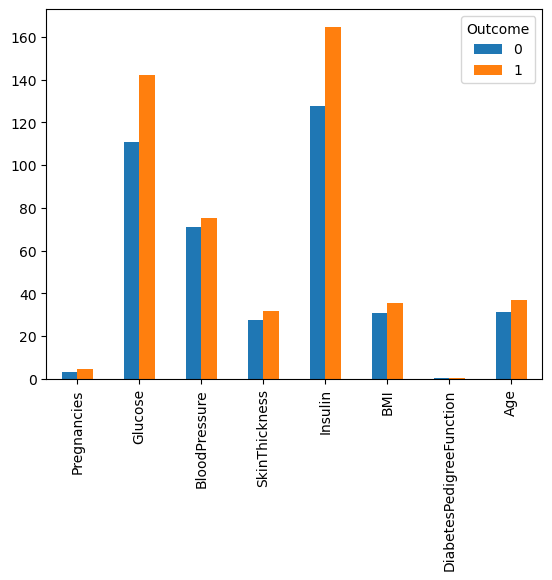

In [21]:
dataset.groupby("Outcome").mean().T.plot(kind="bar")

""" Patients diagnosed with diabetes show significantly higher average glucose levels, BMI, and age compared to non-diabetic patients. """

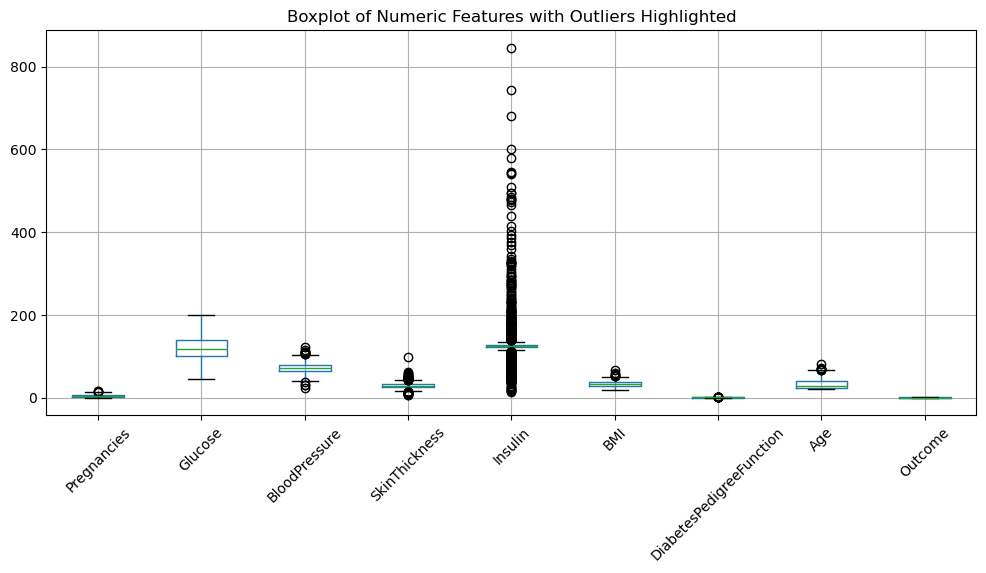

' Boxplots were used to identify potential outliers across numerical features.'

In [22]:
# Boxplots to identify potential outliers across numerical features.
plt.figure(figsize=(12,5))
dataset.boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot of Numeric Features with Outliers Highlighted")
plt.show()
""" Boxplots were used to identify potential outliers across numerical features."""


' The boxplot shows that individuals diagnosed with diabetes have significantly higher glucose levels compared to non-diabetic individuals, indicating that glucose is a strong predictive feature. '

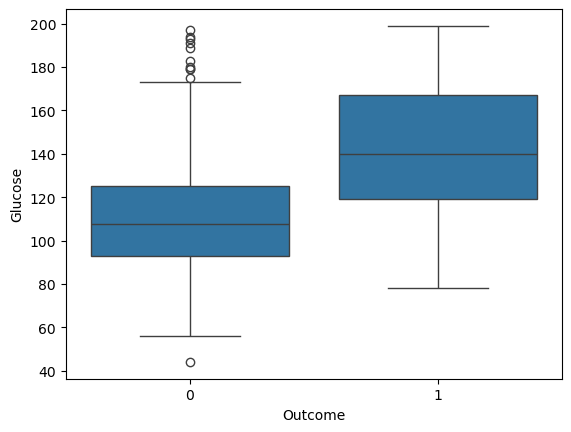

In [23]:
sns.boxplot(x="Outcome", y="Glucose", data=dataset)

""" The boxplot shows that individuals diagnosed with diabetes have significantly higher glucose levels compared to non-diabetic individuals, indicating that glucose is a strong predictive feature. """

' this confirms that insulin has outliers and so is skewed '

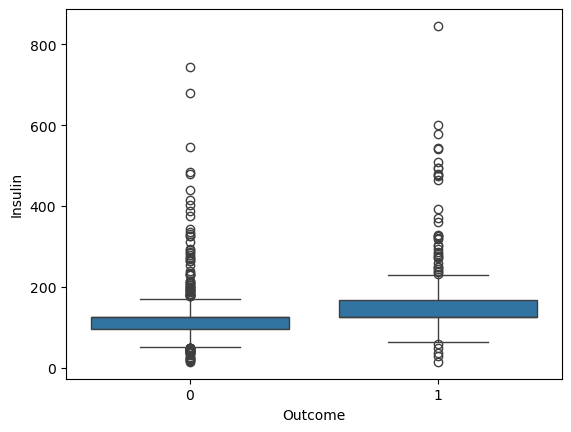

In [24]:
sns.boxplot(x="Outcome", y="Insulin", data=dataset) 

""" this confirms that insulin has outliers and so is skewed """

In [25]:
# Correlation Analysis
# Understand relationships between features.

dataset.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.128213,0.208615,0.081770,0.025047,0.021559,-0.033523,0.544341,0.221898
Glucose,0.128213,1.000000,0.218937,0.192615,0.419451,0.231049,0.137327,0.266909,0.492782
BloodPressure,0.208615,0.218937,1.000000,0.191892,0.045363,0.281257,-0.002378,0.324915,0.165723
SkinThickness,0.081770,0.192615,0.191892,1.000000,0.155610,0.543205,0.102188,0.126107,0.214873
Insulin,0.025047,0.419451,0.045363,0.155610,1.000000,0.180241,0.126503,0.097101,0.203790
BMI,0.021559,0.231049,0.281257,0.543205,0.180241,1.000000,0.153438,0.025597,0.312038
DiabetesPedigreeFunction,-0.033523,0.137327,-0.002378,0.102188,0.126503,0.153438,1.000000,0.033561,0.173844
Age,0.544341,0.266909,0.324915,0.126107,0.097101,0.025597,0.033561,1.000000,0.238356
Outcome,0.221898,0.492782,0.165723,0.214873,0.203790,0.312038,0.173844,0.238356,1.000000


' “Correlation analysis shows that Glucose and BMI have the strongest positive relationship with diabetes outcome, indicating they are key predictive features.”\ndataset.corr() = checks relationships between all numeric features\nHelps you find important predictors  '

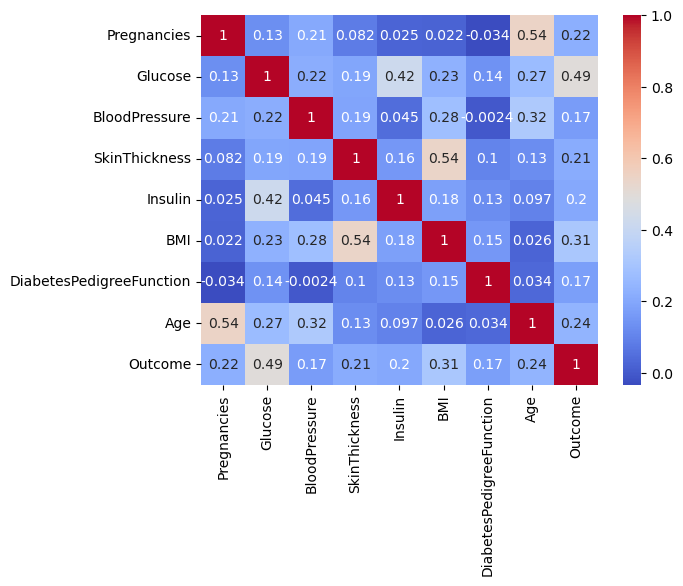

In [26]:
sns.heatmap(dataset.corr(), annot=True, cmap="coolwarm")

""" “Correlation analysis shows that Glucose and BMI have the strongest positive relationship with diabetes outcome, indicating they are key predictive features.”
dataset.corr() = checks relationships between all numeric features
Helps you find important predictors  """

In [27]:
# Flag Outlier-Prone Columns. We’ll use the IQR method to find extreme values.

outlier_cols = []

for col in dataset.columns[:-1]:  # exclude target
    Q1 = dataset[col].quantile(0.25)
    Q3 = dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = dataset[(dataset[col] < Q1 - 1.5*IQR) | 
                             (dataset[col] > Q3 + 1.5*IQR)]
    if len(outliers) > 0:
        outlier_cols.append(col)

print("Columns with potential outliers:", outlier_cols)


Columns with potential outliers: ['Pregnancies', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [28]:
dataset.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [29]:
# log transformation

cols_to_transform = ['Insulin', 'Pregnancies', 'Age', 'DiabetesPedigreeFunction', 'SkinThickness']

for col in cols_to_transform:
    dataset[col + "_log"] = np.log1p(dataset[col])

In [30]:
# Make a copy

dataset_transformed = dataset.copy()

In [31]:
# drop columns

cols_to_drop = ['Insulin', 'Pregnancies', 'Age', 'DiabetesPedigreeFunction', 'SkinThickness']

dataset_transformed = dataset_transformed.drop(columns=cols_to_drop)

In [32]:
dataset_transformed

,Glucose,BloodPressure,BMI,Outcome,Insulin_log,Pregnancies_log,Age_log,DiabetesPedigreeFunction_log,SkinThickness_log
0,148.0,72.0,33.6,1,4.836282,1.945910,3.931826,0.486738,3.583519
1,85.0,66.0,26.6,0,4.836282,0.693147,3.465736,0.300845,3.401197
2,183.0,64.0,23.3,1,4.836282,2.197225,3.496508,0.514021,3.401197
3,89.0,66.0,28.1,0,4.553877,0.693147,3.091042,0.154436,3.178054
4,137.0,40.0,43.1,1,5.129899,0.000000,3.526361,1.190279,3.583519
...,...,...,...,...,...,...,...,...,...
763,101.0,76.0,32.9,0,5.198497,2.397895,4.158883,0.157858,3.891820
764,122.0,70.0,36.8,0,4.836282,1.098612,3.332205,0.292670,3.332205
765,121.0,72.0,26.2,0,4.727388,1.791759,3.433987,0.219136,3.178054
766,126.0,60.0,30.1,1,4.836282,0.693147,3.871201,0.299364,3.401197


In [33]:
# Save as CSV

dataset_transformed.to_csv("cleaned_diabetes.csv", index=False)

# to load in another notebook  --df = pd.read_csv("cleaned_diabetes.csv")

In [34]:
# Save as Pickle (faster for Python):

dataset_transformed.to_pickle("cleaned_diabetes.pkl")

# to load it --df = pd.read_pickle("cleaned_diabetes.pkl")

## The cleaned dataset was saved as cleaned_diabetes.csv for reuse in modeling and evaluation pipelines.